In [1]:
import pandas as pd
import numpy as np

from bsix.models import BaseSurvival, CoxRegression, DeepSurv, RandomSurvForest, SurvTree, DeepMultiTask, CoxRegressionWithTimeVarying, DeepTimeVarying
from bsix.utils import get_data, get_results, compute_metrics, compute_survival_metrics, compute_binary_metrics, get_xai_from_filter, save_results, format_predictions

In [2]:
%matplotlib widget

In [3]:
dataset = "colon.csv"

# Experiments

## Survival analysis (standard)

### Get data

In [4]:
X_train_standard, y_train_standard, X_validation, y_validation, X_test, y_test, train_idx, val_idx, test_idx, feature_names, scaler = get_data(dataset_name=dataset, seed=0)


- - - - colon.csv (csv) - - - -

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   event         911 non-null    int64  
 1   time          911 non-null    int64  
 2   num_age       911 non-null    int64  
 3   num_nodes     911 non-null    float64
 4   fac_rx        911 non-null    object 
 5   fac_sex       911 non-null    int64  
 6   fac_differ    911 non-null    object 
 7   fac_obstruct  911 non-null    int64  
 8   fac_perfor    911 non-null    int64  
 9   fac_adhere    911 non-null    int64  
 10  fac_node4     911 non-null    int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 78.4+ KB

             event         time     num_age   num_nodes fac_rx     fac_sex  \
count   911.000000   911.000000  911.000000  911.000000    911  911.000000   
unique         NaN          NaN         NaN         NaN      3         NaN   
top 

### Instantiate models

In [5]:
modelCoxRegression = CoxRegression()
modelDeepSurv = DeepSurv(X_train_standard.shape[1])
modelRandomSurvForest = RandomSurvForest(seed=0)
modelSurvTree = SurvTree(seed=0)

### Fit and predict

In [6]:
modelCoxRegression = modelCoxRegression.fit(X_train_standard, y_train_standard)
modelDeepSurv = modelDeepSurv.fit(X_train_standard, y_train_standard)
modelRandomSurvForest = modelRandomSurvForest.fit(X_train_standard, y_train_standard)
modelSurvTree = modelSurvTree.fit(X_train_standard, y_train_standard)

survPredCoxRegression = modelCoxRegression.predict(X_test)
survPredDeepSurv = modelDeepSurv.predict(X_test)
survPredRandomSurvForest = modelRandomSurvForest.predict(X_test)
survPredSurvTree = modelSurvTree.predict(X_test)

### Metrics

In [7]:
compute_survival_metrics(y_train_standard, y_test, survPredCoxRegression)

{'C-Index Harrel': 0.6011437635665386,
 'C-Index IPCW': 0.6102418142329669,
 'Cumulative Dinamic AUC': [0.5832670650305211,
  0.6284814887997692,
  0.6584076144438055]}

In [8]:
compute_survival_metrics(y_train_standard, y_test, survPredRandomSurvForest)

{'C-Index Harrel': 0.5831107029554182,
 'C-Index IPCW': 0.5874656674481157,
 'Cumulative Dinamic AUC': [0.5543372531686979,
  0.6176812425592272,
  0.6439015333744376]}

In [9]:
compute_survival_metrics(y_train_standard, y_test, survPredDeepSurv)

{'C-Index Harrel': 0.38165803973952245,
 'C-Index IPCW': 0.38267664366790655,
 'Cumulative Dinamic AUC': [0.3557994480444905,
  0.3432081080835077,
  0.32030302928879917]}

In [10]:
compute_survival_metrics(y_train_standard, y_test, survPredSurvTree)

{'C-Index Harrel': 0.5684170980130239,
 'C-Index IPCW': 0.5735123672962308,
 'Cumulative Dinamic AUC': [0.5249412430715545,
  0.6114112585492893,
  0.6075979492914176]}

### Survival / Cumulative Hazard Functions

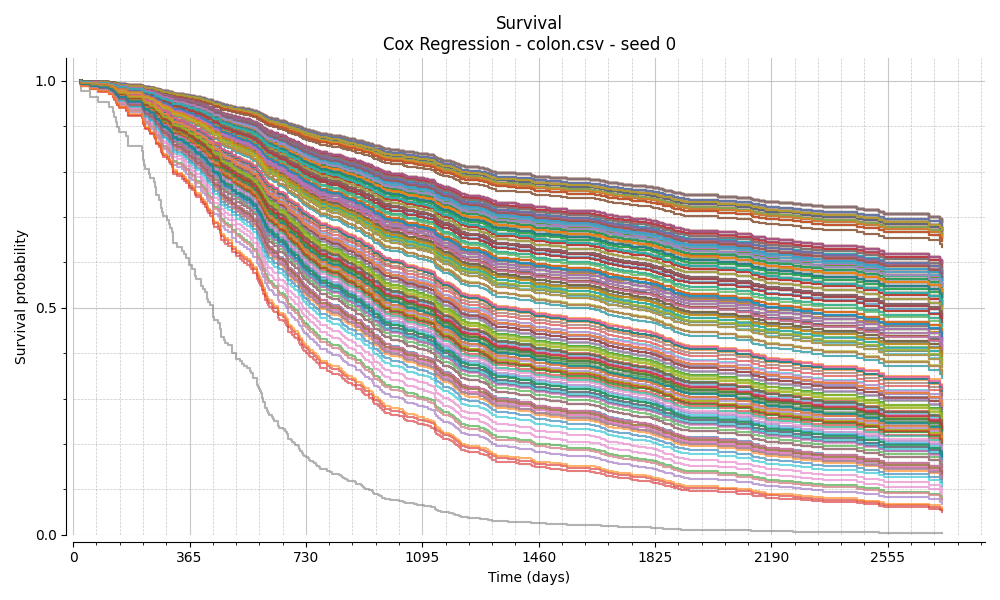

In [11]:
survival_function = modelCoxRegression.predict_survival_function(X=X_train_standard, index=train_idx, dataset=dataset, seed=0, plot=True)

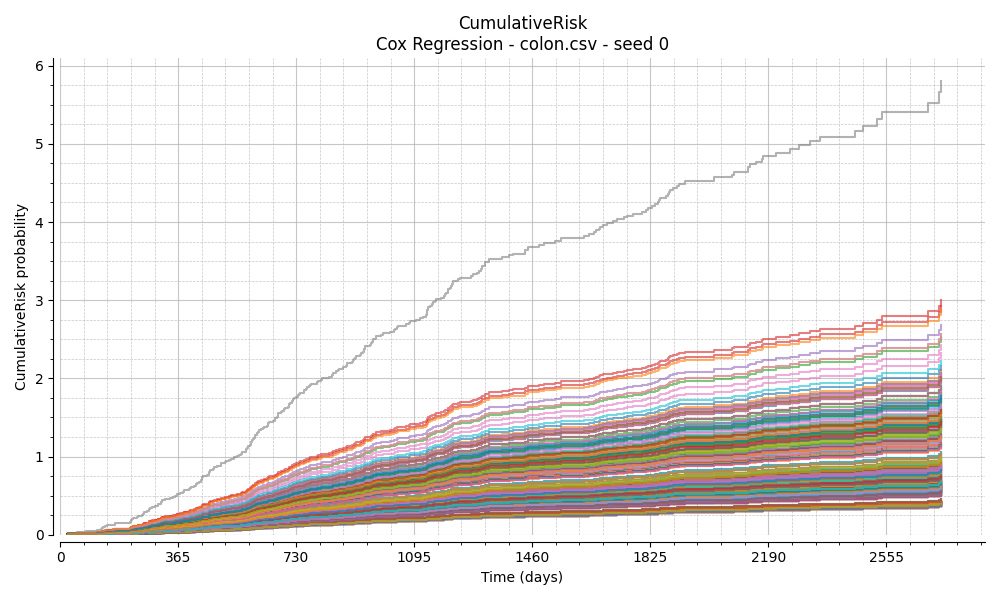

In [12]:
cumulative_hazard_function = modelCoxRegression.predict_cumulative_hazard_function(X=X_train_standard, index=train_idx, dataset=dataset, seed=0, plot=True)

### eXplainable Artificial Intelligence

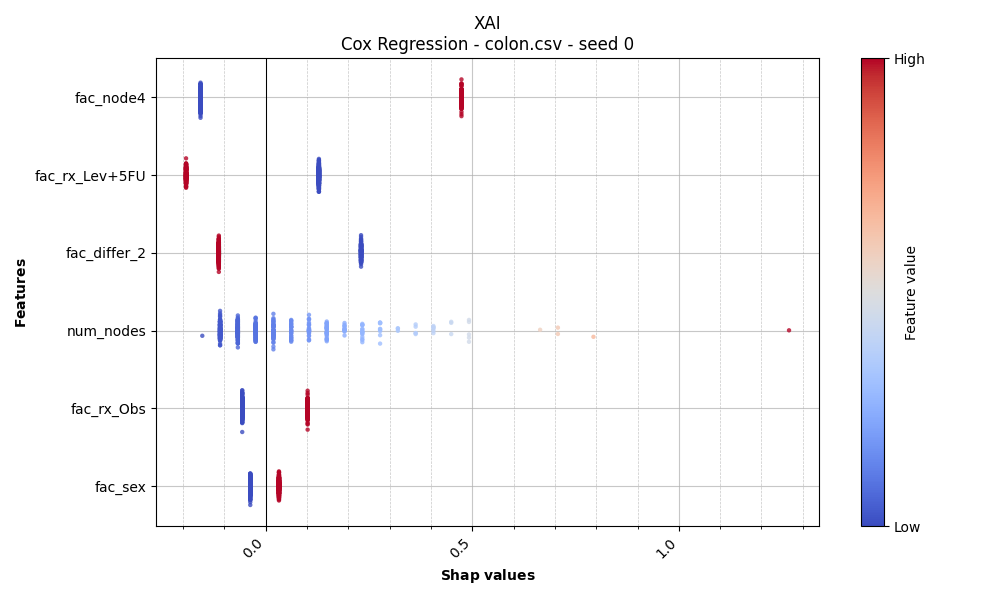

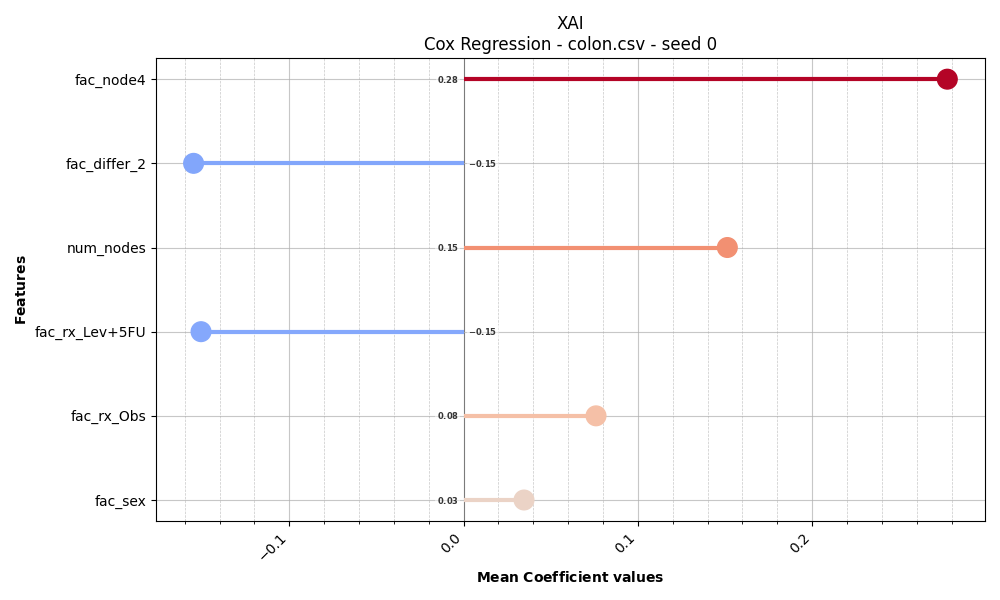

In [13]:
shap_explainer, coefficients = modelCoxRegression.calculate_xai(X=X_train_standard, index=train_idx, scaler=scaler, dataset=dataset, seed=0, feature_names=feature_names, background=None, plot=True)

## Survival analysis (multitask)

### Get data

In [13]:
X_train, y_train, X_validation, y_validation, X_test, y_test, train_idx, val_idx, test_idx, feature_names, scaler = get_data(dataset_name=dataset, to_multitask=True)


- - - - colon.csv (csv) - - - -

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   event         911 non-null    int64  
 1   time          911 non-null    int64  
 2   num_age       911 non-null    int64  
 3   num_nodes     911 non-null    float64
 4   fac_rx        911 non-null    object 
 5   fac_sex       911 non-null    int64  
 6   fac_differ    911 non-null    object 
 7   fac_obstruct  911 non-null    int64  
 8   fac_perfor    911 non-null    int64  
 9   fac_adhere    911 non-null    int64  
 10  fac_node4     911 non-null    int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 78.4+ KB

             event         time     num_age   num_nodes fac_rx     fac_sex  \
count   911.000000   911.000000  911.000000  911.000000    911  911.000000   
unique         NaN          NaN         NaN         NaN      3         NaN   
top 

### Instantiate models

In [14]:
modelDeepMultiTask = DeepMultiTask(X_train.shape[1])

### Fit and predict

In [15]:
modelDeepMultiTask = modelDeepMultiTask.fit(X_train, y_train)
survPredDeepMultiTask = modelDeepMultiTask.predict(X_test)

### Metrics

In [16]:
compute_survival_metrics(y_train, y_test, survPredDeepMultiTask)

{'C-Index Harrel': 0.4906912673234263,
 'C-Index IPCW': 0.49898294600760007,
 'Cumulative Dinamic AUC': [0.5307062954017627,
  0.4848483161758987,
  0.4727407225642997]}

### Survival / Cumulative Hazard Functions

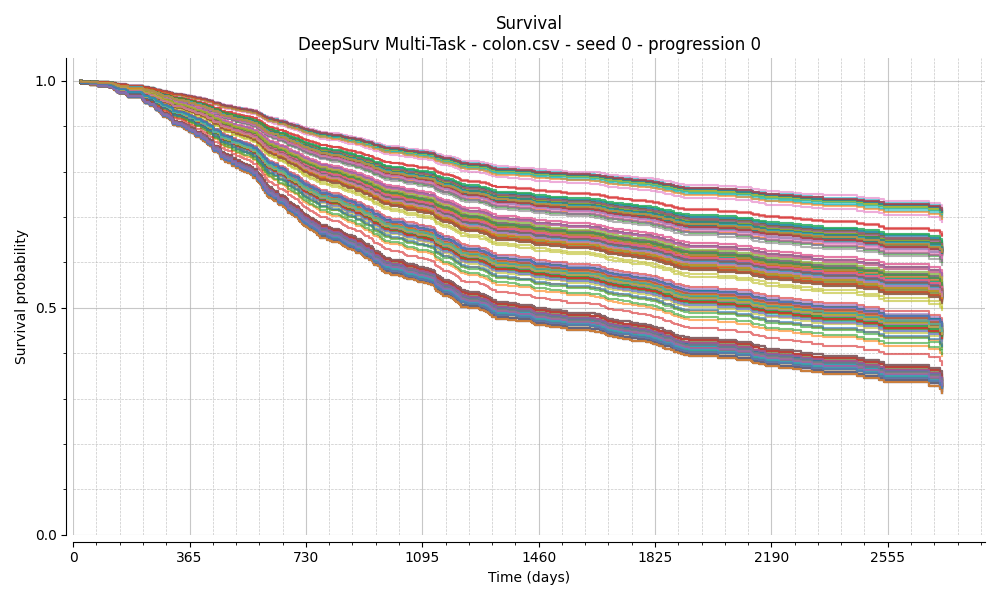

In [17]:
survival_function = modelDeepMultiTask.predict_survival_function(X=X_train, index=train_idx, dataset=dataset, seed=0, plot=True)

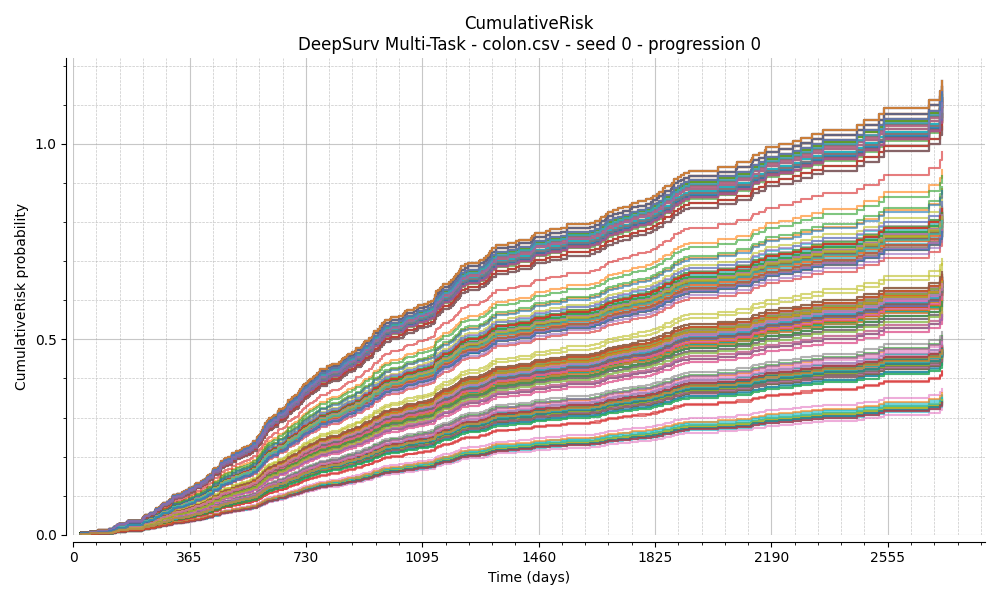

In [18]:
cumulative_hazard_function = modelDeepMultiTask.predict_cumulative_hazard_function(X=X_train, index=train_idx, dataset=dataset, seed=0, plot=True)

### eXplainable Artificial Intelligence

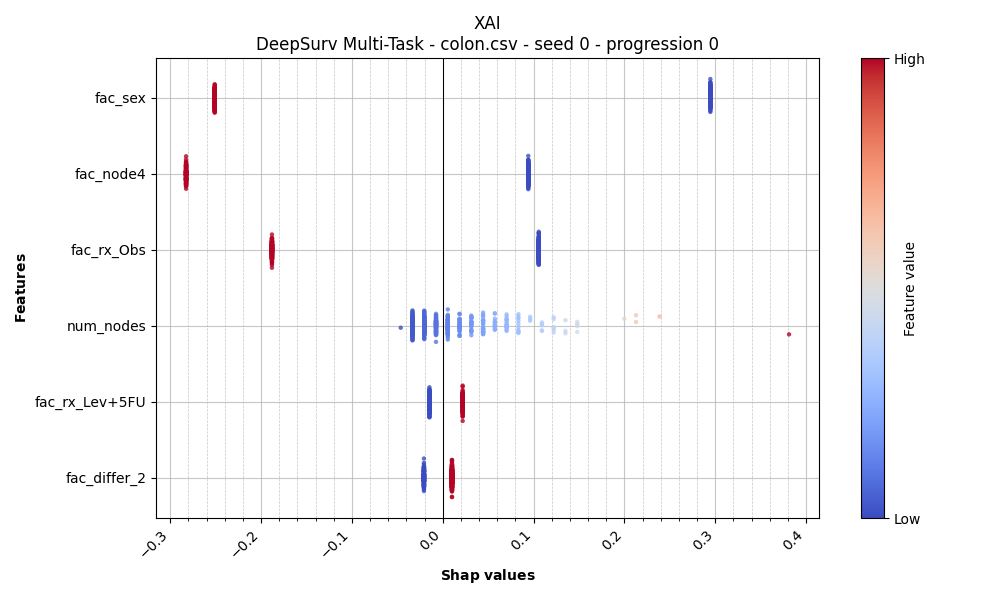

In [19]:
shap_explainer = modelDeepMultiTask.calculate_xai(X=X_train, index=train_idx, scaler=scaler, dataset=dataset, seed=0, feature_names=feature_names, background=None, plot=True)

## Survival analysis (time varying)

In [4]:
df = pd.read_csv(f"./bsix/datasets/{dataset}")

NameError: name 'pd' is not defined

### Find splits dynamically

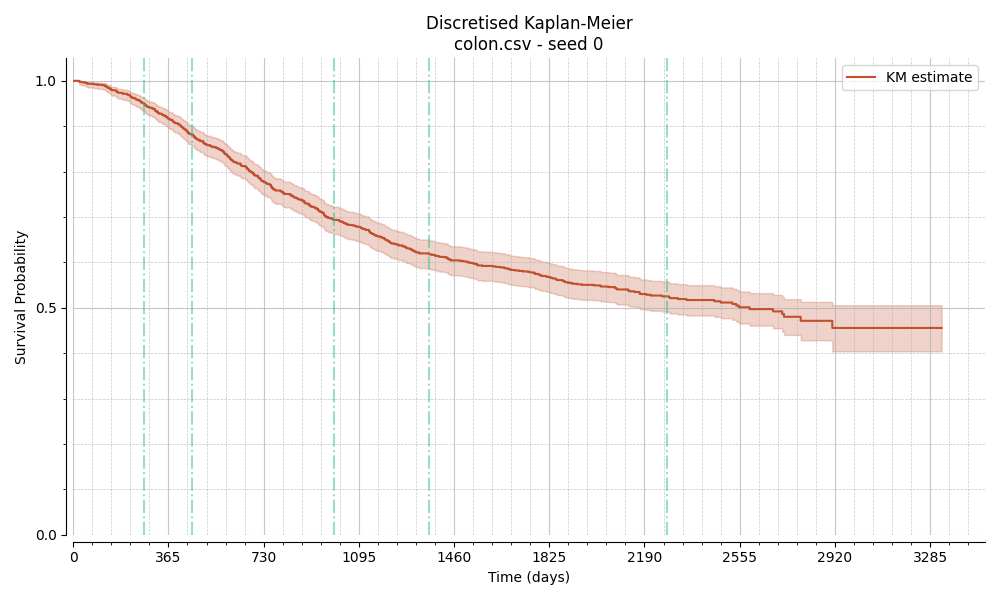

In [22]:
splits = BaseSurvival.dinamic_discretise(y=df[["time", "event"]], dataset=dataset, seed=0, plot=True)

In [23]:
df["identifier"] = df.index.values

### Transform to time varying format

In [24]:
df = BaseSurvival.to_time_dependent(dataframe=df, splits=splits, identifier="identifier", time="time", event="event")

In [25]:
df = BaseSurvival.to_time_varying(dataframe=df, identifier="identifier", time="time", event="event")

### Get data

In [26]:
X_train, y_train, X_validation, y_validation, X_test, y_test, train_idx, val_idx, test_idx, feature_names, scaler = get_data(df=df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4049 entries, 0 to 4048
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   identifier    4049 non-null   int64  
 1   num_age       4049 non-null   int64  
 2   num_nodes     4049 non-null   float64
 3   fac_rx        4049 non-null   object 
 4   fac_sex       4049 non-null   int64  
 5   fac_differ    4049 non-null   object 
 6   fac_obstruct  4049 non-null   int64  
 7   fac_perfor    4049 non-null   int64  
 8   fac_adhere    4049 non-null   int64  
 9   fac_node4     4049 non-null   int64  
 10  event         4049 non-null   int64  
 11  time_start    4049 non-null   float64
 12  time_stop     4049 non-null   float64
dtypes: float64(3), int64(8), object(2)
memory usage: 411.4+ KB

         identifier      num_age    num_nodes   fac_rx      fac_sex  \
count   4049.000000  4049.000000  4049.000000     4049  4049.000000   
unique          NaN          NaN         

### Instantiate models

In [27]:
modelCoxRegressionWithTimeVarying = CoxRegressionWithTimeVarying()
modelDeepTimeVarying = DeepTimeVarying(X_train.shape[1])

### Fit and predict

In [28]:
modelCoxRegressionWithTimeVarying = modelCoxRegressionWithTimeVarying.fit(X_train, y_train)
modelDeepTimeVarying = modelDeepTimeVarying.fit(X_train, y_train)

survPredCoxRegressionWithTimeVarying = modelCoxRegressionWithTimeVarying.predict(X_test)
survPredDeepTimeVarying = modelDeepTimeVarying.predict(X_test)

### Metrics

In [29]:
compute_survival_metrics(y_train, y_test, survPredCoxRegressionWithTimeVarying)

{'C-Index Harrel': 0.6355955375697254,
 'C-Index IPCW': 0.6332035502395869,
 'Cumulative Dinamic AUC': [0.6363646563838035,
  0.6488692045509804,
  0.6189078114020805]}

In [30]:
compute_survival_metrics(y_train, y_test, survPredDeepTimeVarying)

{'C-Index Harrel': 0.4374111342010281,
 'C-Index IPCW': 0.3930572667273808,
 'Cumulative Dinamic AUC': [0.43045043664299293,
  0.40767910311271555,
  0.35192563510494984]}

### Survival / Cumulative Hazard Functions

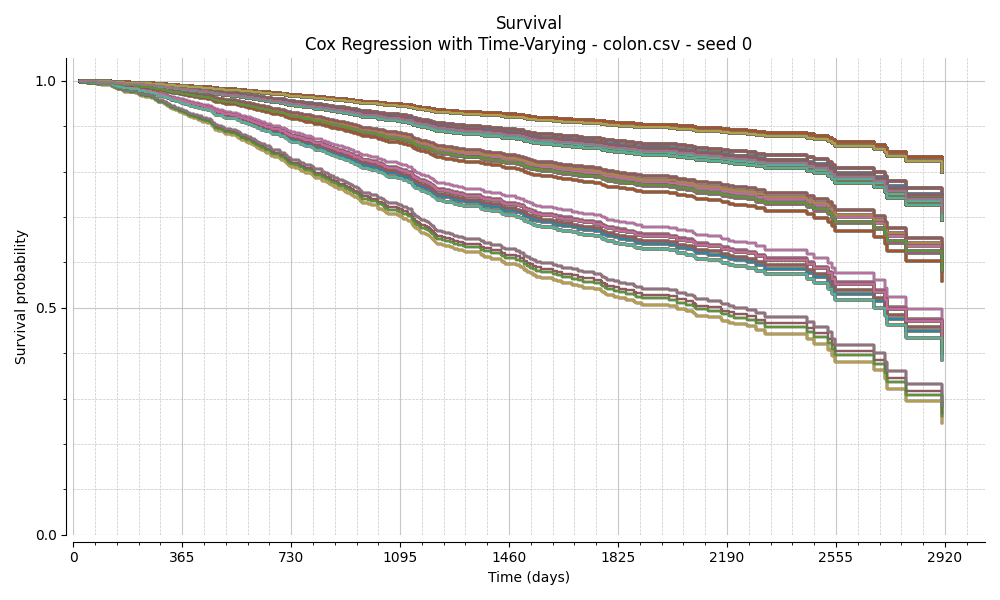

In [31]:
survival_function = modelCoxRegressionWithTimeVarying.predict_survival_function(X=X_train, index=train_idx, dataset=dataset, seed=0, plot=True)

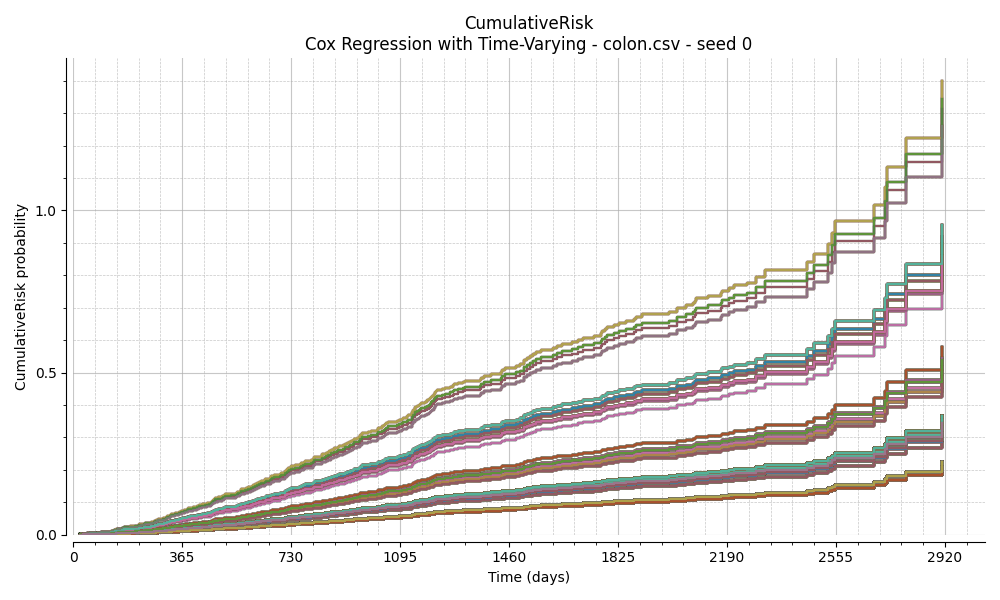

In [32]:
cumulative_hazard_function = modelCoxRegressionWithTimeVarying.predict_cumulative_hazard_function(X=X_train, index=train_idx, dataset=dataset, seed=0, plot=True)

### eXplainable Artificial Intelligence

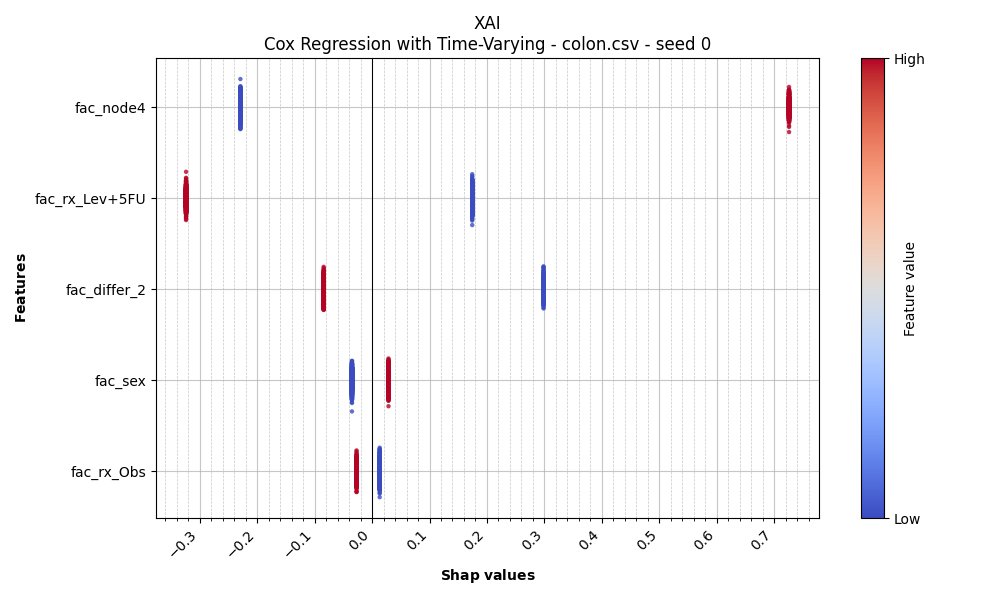

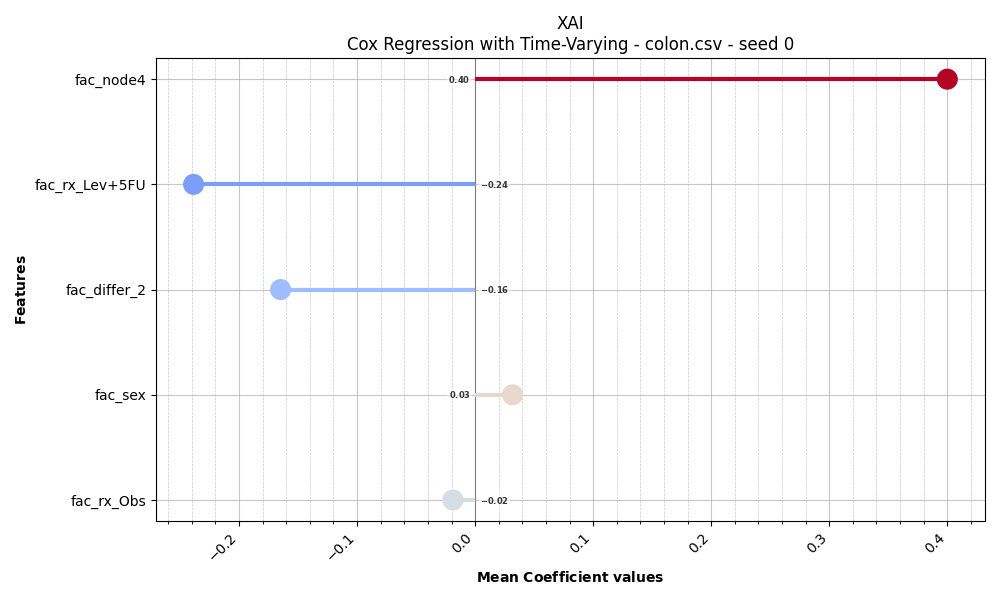

In [33]:
shap_explainer, coefficients = modelCoxRegressionWithTimeVarying.calculate_xai(X=X_train, index=train_idx, scaler=scaler, dataset=dataset, seed=0, feature_names=feature_names, background=None, plot=True)

## Tools

### Feature selector

In [34]:
features_selected = BaseSurvival.feature_selection(X_train_standard, y_train_standard)

In [35]:
print(f"ALL FEATURES: {X_train_standard.shape}, SELECTED FEATURES: {X_train_standard[:, features_selected].shape}")

ALL FEATURES: (582, 6), SELECTED FEATURES: (582, 4)


### Simulated survival data

In [36]:
BaseSurvival.generate_simulated_survival_data(number_rows=1000, number_columns=10, censored=0.75, relation="sin", seed=0)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,event,time
0,1.764052,0.400157,0.978738,2.240893,1.867558,-0.977278,0.950088,-0.151357,-0.103219,0.410599,0,7.39
1,0.144044,1.454274,0.761038,0.121675,0.443863,0.333674,1.494079,-0.205158,0.313068,-0.854096,1,82.31
2,-2.552990,0.653619,0.864436,-0.742165,2.269755,-1.454366,0.045759,-0.187184,1.532779,1.469359,1,5.16
3,0.154947,0.378163,-0.887786,-1.980796,-0.347912,0.156349,1.230291,1.202380,-0.387327,-0.302303,1,3.00
4,-1.048553,-1.420018,-1.706270,1.950775,-0.509652,-0.438074,-1.252795,0.777490,-1.613898,-0.212740,0,2.93
...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.622801,1.240477,0.170446,1.986898,0.111301,1.209655,-0.457330,0.923183,1.325519,-0.953166,0,0.53
996,-0.678130,0.334100,-0.754928,-0.388383,-0.626576,-1.306421,-0.038496,0.143567,-0.789074,-0.098504,0,0.09
997,-1.452866,-0.947866,-0.869579,-0.305517,-0.605147,0.224821,-1.038472,0.771819,-0.480009,1.834745,0,0.06
998,-0.108765,0.454475,0.098709,-0.458305,-0.857044,-0.774403,0.708787,0.018474,-0.104081,-0.234858,0,0.33


### Log-rank test

In [37]:
identifier = np.arange(len(X_train_standard))

In [38]:
# H0 = "There is no difference in the survival curves between the groups analysed" (p-value < threshold ==> reject H0)
a = BaseSurvival.logrank_test(y_train_standard, identifier)

# Results

## Show stored results

In [ ]:
results = get_results(result_folder="./results", estimator_name=None, dataset=None)
#results = get_results(estimator_name="CoxRegressionWithTimeVarying", dataset="cgd.csv")
#results = get_results(estimator_name="DeepMultiTaskFFNN", dataset=dataset)

In [ ]:
for i, result in enumerate(results):
    print(f"Result {i}:\n")
    print(f"    * Estimator: {result.config['estimator_name']} - Dataset: {result.config['dataset']} - Seed: {result.config['random_state']}")
    print(f"    * Best Params: {result.data_.best_params}")
    print()
    print(f"    * Metrics: {compute_metrics(result.data_.train_targets[1], result.data_.targets[1], result.data_.predictions)}")
    # print(f"    * Features: {result.data_.best_model.scaler_.feature_names_in_}")
    print("\n\n")

## Plot XAI results 

In [ ]:
get_xai_from_filter(result_folder="./results", estimator_name="CoxRegression", dataset=dataset, seed=None, identifier_index=184)
#get_xai(estimator_name="CoxRegression", dataset=dataset)
#get_xai(dataset=dataset)

## Save stored results 

In [ ]:
save_results(result_folder="./results", estimator_name=None, dataset=None)

---

## Pruebas

### Tiempo de cómputo

In [ ]:
from sksurv.tree import SurvivalTree
estimator = SurvivalTree(max_depth=None, min_samples_split=6, min_samples_leaf=3, random_state=0).fit(X_train_standard, y_train_standard)
predictions = estimator.predict(X_test)
compute_survival_metrics(y_train_standard, y_test, predictions)

In [ ]:
a = estimator.predict_survival_function(X_train_standard)

In [ ]:
from bsix.models import SurvTree
estimator = SurvTree(max_depth=None, min_samples_split=6, min_samples_leaf=3, random_state=0).fit(X_train_standard, y_train_standard)
predictions = estimator.predict(X_test)
compute_survival_metrics(y_train_standard, y_test, predictions)

In [ ]:
b = estimator.predict_survival_function(X_train_standard, train_idx, dataset, 0, True)

In [ ]:
from sksurv.linear_model import CoxPHSurvivalAnalysis
estimator = CoxPHSurvivalAnalysis().fit(X_train_standard, y_train_standard)
predictions = estimator.predict(X_test)
compute_survival_metrics(y_train_standard, y_test, predictions)

In [ ]:
from bsix.models import CoxRegression
estimator = CoxRegression().fit(X_train_standard, y_train_standard)
predictions = estimator.predict(X_test)
compute_survival_metrics(y_train_standard, y_test, predictions)

---

### Comparativa: Base vs Propios

In [ ]:
df = pd.read_csv(f"comparativa.csv")

In [ ]:
df

,dataset,estimator_name,random_state,C-Index Harrel,C-Index IPCW,time
0,acath.csv,BaseCoxRegression,14.5,0.570050,0.567262,6.415449
1,acath.csv,BaseCoxRegressionWithTimeVarying,14.5,0.500000,0.500000,6.409223
2,acath.csv,BaseRandomSurvivalForest,14.5,0.570050,0.567262,16.567884
3,acath.csv,BaseSurvivalTree,14.5,0.570050,0.567262,6.977800
4,acath.csv,CoxRegression,14.5,0.570050,0.567262,6.808431
...,...,...,...,...,...,...
187,wpbc.csv,BaseSurvivalTree,14.5,0.570286,0.572911,5.445057
188,wpbc.csv,CoxRegression,14.5,0.654471,0.634866,5.826412
189,wpbc.csv,CoxRegressionWithTimeVarying,14.5,0.676984,0.670330,6.322080
190,wpbc.csv,RandomSurvForest,14.5,0.607821,0.593371,19.596392


In [ ]:
for estimator in df.groupby("estimator_name"):
    print(estimator[0])
    print(estimator[1][["C-Index Harrel", "C-Index IPCW", "time"]].mean())

BaseCoxRegression
C-Index Harrel    0.620006
C-Index IPCW      0.607641
time              6.507011
dtype: float64
BaseCoxRegressionWithTimeVarying
C-Index Harrel     0.588889
C-Index IPCW       0.575360
time              17.397069
dtype: float64
BaseRandomSurvivalForest
C-Index Harrel     0.618298
C-Index IPCW       0.604632
time              48.787391
dtype: float64
BaseSurvivalTree
C-Index Harrel    0.602236
C-Index IPCW      0.591881
time              6.248110
dtype: float64
CoxRegression
C-Index Harrel    0.617531
C-Index IPCW      0.605070
time              8.021205
dtype: float64
CoxRegressionWithTimeVarying
C-Index Harrel     0.630398
C-Index IPCW       0.613353
time              13.154188
dtype: float64
RandomSurvForest
C-Index Harrel      0.618549
C-Index IPCW        0.603090
time              332.591380
dtype: float64
SurvTree
C-Index Harrel    0.599557
C-Index IPCW      0.589904
time              8.329693
dtype: float64


---

### Eliminar

In [ ]:
# filtered_results = get_results(result_folder="./results", estimator_name="RandomSurvForest", dataset=None)

# for result in filtered_results:
#    print(f"Deleting the result {result}")
#    # Delete the result from disk
#    result.delete()